<!-- Reemplaza USUARIO/REPO por tu repositorio para activar el badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/04_masacres_conflicto_armado_colombia.ipynb)

# 4.627 masacres: lo que los datos revelan sobre el conflicto armado colombiano

**Análisis exploratorio del registro del Observatorio de Memoria y Conflicto**
*1947–2024 · 26 variables · Datos Abiertos de Colombia*

Luis Javier Rubio Hernández

---

El dataset registra 4.627 masacres del conflicto armado colombiano. Detrás de cada fila hay
personas, comunidades y municipios que dejaron de ser lo que eran. El análisis que sigue es
técnico porque esa es la forma de tratarlo con seriedad, no porque el objeto lo sea.

Una masacre se define, en este registro, como el asesinato intencional de cuatro o más personas
en estado de indefensión. Ese umbral importa para leer los resultados: la distribución de
víctimas por caso está truncada por la izquierda en 4, y eso condiciona todos los estadísticos de
posición.

**Qué se hace aquí**

1. Reconstrucción del dato desde el archivo publicado, con el tratamiento de los separadores de
   miles y la geometría en formato WKT.
2. Auditoría de calidad: faltantes, duplicados, valores imposibles y normalidad.
3. Evolución temporal, autoría, distribución geográfica y escala.
4. Estructura de coocurrencia entre hechos victimizantes simultáneos.

## 0. Configuración y carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

AZUL, GRIS, TEXTO, GRIS_OSC, ROJO = "#0073B1", "#D4D4D4", "#333333", "#767676", "#C0392B"

mpl.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.8),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": GRIS_OSC, "axes.titlecolor": TEXTO,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "xtick.color": GRIS_OSC, "ytick.color": GRIS_OSC,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "grid.color": "#EEEEEE",
})
pd.set_option("display.width", 150)

In [2]:
# Reemplaza USUARIO/REPO por tu repositorio. La copia local sirve de respaldo.
URL = ("https://raw.githubusercontent.com/USUARIO/REPO/main/datos/"
       "masacres_omc_colombia.csv")
LOCAL = "masacres_omc_colombia.csv"

try:
    crudo = pd.read_csv(URL, dtype=str)
    print("Origen: repositorio remoto")
except Exception:
    crudo = pd.read_csv(LOCAL, dtype=str)
    print("Origen: copia local junto al cuaderno")

print(f"Dimensiones: {crudo.shape[0]:,} casos x {crudo.shape[1]} variables")
crudo.iloc[:3, :11]

Origen: copia local junto al cuaderno
Dimensiones: 4,627 casos x 26 variables


,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,Presunto Responsable
0,"100,649",CR030032,"1,998",1,25,25530,PARATEBUENO,CUNDINAMARCA,PIEDEMONTE LLANERO,RUTA,GRUPO PARAMILITAR
1,"102,446",NaN,"2,007",10,17,27361,ISTMINA,CHOCO,VALLE DE SAN JUAN,ENGAÑO,GRUPO POSDESMOVILIZACIÓN
2,"105,517",NaN,"2,005",12,7,44430,MAICAO,LA GUAJIRA,ALTA GUAJIRA,ASALTO,GRUPO PARAMILITAR


### 0.1 Un detalle de formato que hay que resolver antes de contar nada

El archivo publica **todos** los campos entre comillas y con separador de miles, incluidos los
que no son cantidades: el año 1998 aparece como `"1,998"`. Leído sin tratamiento, cualquier
operación temporal falla en silencio. Las coordenadas vienen en formato WKT (`POINT (lon lat)`)
y hay que extraerlas.

In [3]:
d = crudo.copy()

enteros = ["Año", "Mes", "Día", "Código DANE de Municipio", "Total de Víctimas del Caso"]
hechos = ["Abandono o Despojo Forzado de Tierras", "Amenaza o Intimidación",
          "Ataque Contra Misión Médica", "Confinamiento o Restricción a la Movilidad",
          "Desplazamiento Forzado", "Extorsión", "Lesionados Civiles", "Pillaje", "Tortura"]

for c in enteros + hechos:
    d[c] = pd.to_numeric(d[c].str.replace(",", "", regex=False), errors="coerce")

coord = d["latitud-longitud"].str.extract(r"POINT \(([-\d.]+) ([-\d.]+)\)")
d["longitud"] = pd.to_numeric(coord[0], errors="coerce")
d["latitud"] = pd.to_numeric(coord[1], errors="coerce")

print(f"Año leído sin tratamiento : {crudo['Año'].iloc[0]!r}")
print(f"Año tras el tratamiento   : {d['Año'].iloc[0]}")
print(f"Coordenadas extraídas     : {d[['latitud', 'longitud']].notna().all(axis=1).sum():,} "
      f"de {len(d):,} casos")

Año leído sin tratamiento : '1,998'
Año tras el tratamiento   : 1998
Coordenadas extraídas     : 4,627 de 4,627 casos


## 1. Auditoría de calidad

Un registro de memoria histórica no se evalúa solo por lo que contiene sino por lo que le falta,
y por qué le falta.

In [4]:
na = d[crudo.columns].isna().sum()
na = na[na > 0].sort_values(ascending=False)

calidad = pd.DataFrame({
    "Variable": na.index,
    "Faltantes": na.values,
    "% del total": (100*na.values/len(d)).round(2),
})
print(calidad.to_string(index=False))
print(f"\n{crudo.shape[1]-len(na)} de {crudo.shape[1]} variables no presentan faltantes.")

                  Variable  Faltantes  % del total
Violencia Basada en Género       4612        99.68
     Otro Hecho Simultáneo       4419        95.50
       ID Caso Relacionado       3913        84.57
                    Región         44         0.95
  Código DANE de Municipio          6         0.13
             Tipo de Armas          2         0.04

20 de 26 variables no presentan faltantes.


In [5]:
# Duplicados: los identificadores hacen único cualquier registro, de modo que la pregunta
# correcta es si hay casos idénticos en todo lo demás.
dup_todo = int(d[crudo.columns].duplicated().sum())
sin_ids = [c for c in crudo.columns if c not in ("ID Caso", "ID Caso Relacionado")]
dup_contenido = int(d[sin_ids].duplicated().sum())

print(f"Filas idénticas incluyendo identificadores : {dup_todo}")
print(f"Filas idénticas en todo salvo los ID       : {dup_contenido}")
print("\nEsos casos comparten municipio, fecha, responsable, modalidad, armamento y número de")
print("víctimas. Pueden ser registros repetidos o eventos distintos con las mismas")
print("características; el dataset no permite distinguirlo, y esa ambigüedad debe declararse.")

# Valores imposibles en el campo temporal
anio_cero = int((d["Año"] == 0).sum())
print(f"\nCasos con año igual a 0: {anio_cero} "
      f"({100*anio_cero/len(d):.2f} %) — fecha desconocida codificada como cero,")
print("no como faltante. Se excluyen de todo análisis temporal, no del conteo de casos.")

vbg = d["Violencia Basada en Género"].notna().sum()
print(f"\nViolencia Basada en Género: solo {vbg} registros con información "
      f"({100*(1-vbg/len(d)):.1f} % vacío).")
print("Un subregistro de esa magnitud impide cualquier afirmación sobre la dimensión de género.")

Filas idénticas incluyendo identificadores : 0
Filas idénticas en todo salvo los ID       : 17

Esos casos comparten municipio, fecha, responsable, modalidad, armamento y número de
víctimas. Pueden ser registros repetidos o eventos distintos con las mismas
características; el dataset no permite distinguirlo, y esa ambigüedad debe declararse.

Casos con año igual a 0: 22 (0.48 %) — fecha desconocida codificada como cero,
no como faltante. Se excluyen de todo análisis temporal, no del conteo de casos.

Violencia Basada en Género: solo 15 registros con información (99.7 % vacío).
Un subregistro de esa magnitud impide cualquier afirmación sobre la dimensión de género.


La lección metodológica es la del propio informe de la Comisión de la Verdad: este dataset es
imprescindible y a la vez incompleto. Lo que no está registrado no es lo que no ocurrió.

## 2. Escala: la distribución de víctimas por caso

In [6]:
v = d["Total de Víctimas del Caso"]

resumen = pd.Series({
    "Casos": v.size, "Víctimas totales": v.sum(),
    "Media": v.mean(), "Mediana": v.median(), "Desv. estándar": v.std(),
    "Mínimo": v.min(), "Q3": v.quantile(.75), "Máximo": v.max(),
    "Asimetría": stats.skew(v), "Curtosis (exceso)": stats.kurtosis(v),
})
print(resumen.apply(lambda x: f"{x:,.2f}").to_string())

sw = stats.shapiro(v)
print(f"\nShapiro-Wilk: W = {sw.statistic:.4f}, p = {sw.pvalue:.2e}  -> se rechaza normalidad")
print(f"Municipios afectados: {d['Municipio'].nunique()}   "
      f"Departamentos: {d['Departamento'].nunique()}")
print(f"\nEl 50 % de los casos tiene 5 víctimas o menos, pero el máximo es {v.max():.0f}. "
      f"La cola pesada\n(curtosis {stats.kurtosis(v):.1f}) obliga a usar la mediana y pruebas "
      f"no paramétricas en todo lo que sigue.")

Casos                 4,627.00
Víctimas totales     27,583.00
Media                     5.96
Mediana                   5.00
Desv. estándar            4.35
Mínimo                    4.00
Q3                        6.00
Máximo                  126.00
Asimetría                 8.83
Curtosis (exceso)       158.58

Shapiro-Wilk: W = 0.4344, p = 6.10e-81  -> se rechaza normalidad
Municipios afectados: 687   Departamentos: 33

El 50 % de los casos tiene 5 víctimas o menos, pero el máximo es 126. La cola pesada
(curtosis 158.6) obliga a usar la mediana y pruebas no paramétricas en todo lo que sigue.


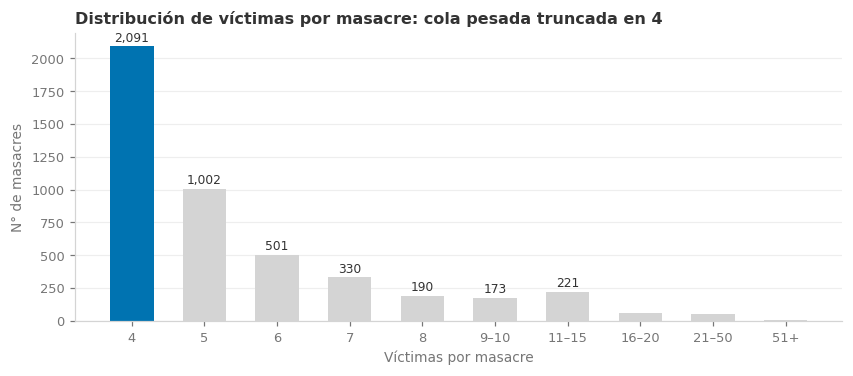

In [7]:
cortes = [4, 5, 6, 7, 8, 11, 16, 21, 51, 200]
etiquetas = ["4", "5", "6", "7", "8", "9–10", "11–15", "16–20", "21–50", "51+"]
grupos = pd.cut(v, bins=[3, 4, 5, 6, 7, 8, 10, 15, 20, 50, 200],
                labels=["4", "5", "6", "7", "8", "9–10", "11–15", "16–20", "21–50", "51+"])
conteo = grupos.value_counts().reindex(
    ["4", "5", "6", "7", "8", "9–10", "11–15", "16–20", "21–50", "51+"])

fig, ax = plt.subplots(figsize=(9, 3.4))
colores = [AZUL] + [GRIS]*(len(conteo)-1)
barras = ax.bar(conteo.index.astype(str), conteo.values, color=colores, width=.6)
for b, val in zip(barras, conteo.values):
    if val > 100:
        ax.text(b.get_x()+b.get_width()/2, val+40, f"{val:,}", ha="center",
                fontsize=8, color=TEXTO)
ax.set_xlabel("Víctimas por masacre"); ax.set_ylabel("N° de masacres")
ax.set_title("Distribución de víctimas por masacre: cola pesada truncada en 4")
ax.grid(axis="y"); ax.set_axisbelow(True)
plt.show()

## 3. Evolución temporal

El período 1996–2003 es el eje de la narrativa habitual sobre el conflicto. Conviene medirlo en
lugar de afirmarlo: las cifras de esta celda salen del archivo, no de una redacción previa.

In [8]:
dt = d[d["Año"] > 0]        # se excluyen las fechas desconocidas

por_anio = dt.groupby("Año").agg(masacres=("ID Caso", "size"),
                                 victimas=("Total de Víctimas del Caso", "sum"))

pico = por_anio["masacres"].idxmax()
p9603 = por_anio.loc[1996:2003]

print(f"Período cubierto: {int(dt['Año'].min())}–{int(dt['Año'].max())}")
print(f"Año pico: {int(pico)} con {int(por_anio.loc[pico, 'masacres'])} masacres y "
      f"{int(por_anio.loc[pico, 'victimas']):,} víctimas")
print(f"\n1996–2003: {int(p9603['masacres'].sum()):,} masacres y "
      f"{int(p9603['victimas'].sum()):,} víctimas")
print(f"  {100*p9603['masacres'].sum()/len(dt):.1f} % de todas las masacres del registro "
      f"en 8 de los {int(dt['Año'].nunique())} años con datos")
print(f"  {100*p9603['victimas'].sum()/dt['Total de Víctimas del Caso'].sum():.1f} % "
      f"de las víctimas")
print(f"\n1988–1995: promedio de {por_anio.loc[1988:1995,'masacres'].mean():.0f} masacres/año")
print(f"1996–2003: promedio de {p9603['masacres'].mean():.0f} masacres/año  "
      f"(factor {p9603['masacres'].mean()/por_anio.loc[1988:1995,'masacres'].mean():.1f})")
print(f"2002: {int(por_anio.loc[2002,'masacres'])} masacres  ->  "
      f"2016: {int(por_anio.loc[2016,'masacres'])}  (desmovilización de las AUC)")
print(f"2020: {int(por_anio.loc[2020,'masacres'])} masacres (repunte por disidencias)")

Período cubierto: 1947–2024
Año pico: 2001 con 401 masacres y 2,340 víctimas

1996–2003: 2,184 masacres y 12,344 víctimas
  47.4 % de todas las masacres del registro en 8 de los 78 años con datos
  45.0 % de las víctimas

1988–1995: promedio de 111 masacres/año
1996–2003: promedio de 273 masacres/año  (factor 2.5)
2002: 325 masacres  ->  2016: 4  (desmovilización de las AUC)
2020: 30 masacres (repunte por disidencias)


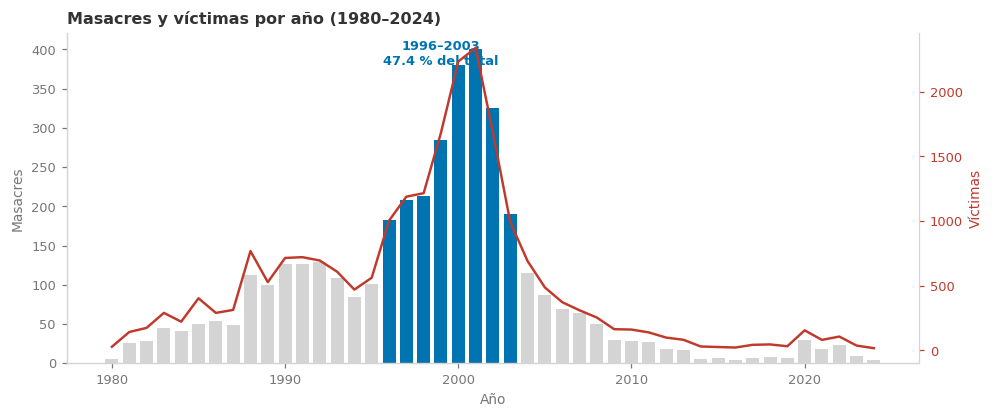

In [9]:
rango = por_anio.loc[1980:2024]
fig, ax = plt.subplots(figsize=(10, 3.9))

colores = [AZUL if 1996 <= a <= 2003 else GRIS for a in rango.index]
ax.bar(rango.index, rango["masacres"], color=colores, width=.75)
ax.set_ylabel("Masacres"); ax.set_xlabel("Año")
ax.set_title("Masacres y víctimas por año (1980–2024)")

ax2 = ax.twinx()
ax2.plot(rango.index, rango["victimas"], color=ROJO, lw=1.6)
ax2.set_ylabel("Víctimas", color=ROJO)
ax2.tick_params(axis="y", colors=ROJO)
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(GRIS)

ax.annotate(f"1996–2003\n{100*p9603['masacres'].sum()/len(dt):.1f} % del total",
            xy=(1999, 380), fontsize=8.5, color=AZUL, ha="center", fontweight="bold")
plt.show()

## 4. Presuntos responsables

La atribución de autoría es la variable más delicada del registro. Se reporta tal como fue
codificada, sin agrupar categorías que el propio dataset distingue.

In [10]:
resp = d.groupby("Presunto Responsable").agg(
    masacres=("ID Caso", "size"),
    victimas=("Total de Víctimas del Caso", "sum"),
    media=("Total de Víctimas del Caso", "mean"),
    mediana=("Total de Víctimas del Caso", "median"),
).sort_values("masacres", ascending=False)
resp["% masacres"] = 100*resp["masacres"]/len(d)

print(resp.round(1).to_string())
print(f"\nLos grupos paramilitares concentran el {resp.loc['GRUPO PARAMILITAR','% masacres']:.1f} % "
      f"de los casos y {resp.loc['GRUPO PARAMILITAR','victimas']:,.0f} víctimas.")

                                       masacres  victimas  media  mediana  % masacres
Presunto Responsable                                                                 
GRUPO PARAMILITAR                          2087     12097    5.8      5.0        45.1
GUERRILLA                                   779      4486    5.8      5.0        16.8
GRUPO ARMADO NO IDENTIFICADO                603      3441    5.7      4.0        13.0
BANDOLERISMO                                409      3229    7.9      5.0         8.8
AGENTE DEL ESTADO                           339      2023    6.0      5.0         7.3
DESCONOCIDO                                 200      1069    5.3      4.0         4.3
GRUPO POSDESMOVILIZACIÓN                    112       569    5.1      4.0         2.4
AGENTE DEL ESTADO - GRUPO PARAMILITAR        39       327    8.4      5.0         0.8
GRUPO ARMADO NO DIRIMIDO                     39       228    5.8      5.0         0.8
OTRO ¿CUÁL?                                  17       

La media de víctimas por caso difiere entre responsables —bandolerismo destaca con 7,9 frente a
5,8 de paramilitares y guerrilla—. Como la distribución no es normal, la comparación se hace con
**Kruskal-Wallis**, y el tamaño del efecto con $\varepsilon^2 = (H-k+1)/(n-k)$.

In [11]:
principales = resp.index[:6]
muestras = [d.loc[d["Presunto Responsable"] == r, "Total de Víctimas del Caso"].dropna()
            for r in principales]

H, p = stats.kruskal(*muestras)
k, n = len(muestras), sum(len(m) for m in muestras)
eps2 = (H - k + 1)/(n - k)

print(f"Kruskal-Wallis sobre {k} grupos, n = {n:,}")
print(f"  H = {H:.2f}   p = {p:.3e}")
print(f"  epsilon² = {eps2:.4f}  -> las diferencias son significativas pero de magnitud pequeña")
print("\nEs el mismo patrón del caso anterior: con miles de observaciones, la significancia")
print("estadística llega antes que la relevancia práctica. La escala de una masacre no depende")
print("apreciablemente de quién la comete.")

Kruskal-Wallis sobre 6 grupos, n = 4,417
  H = 68.80   p = 1.818e-13
  epsilon² = 0.0145  -> las diferencias son significativas pero de magnitud pequeña

Es el mismo patrón del caso anterior: con miles de observaciones, la significancia
estadística llega antes que la relevancia práctica. La escala de una masacre no depende
apreciablemente de quién la comete.


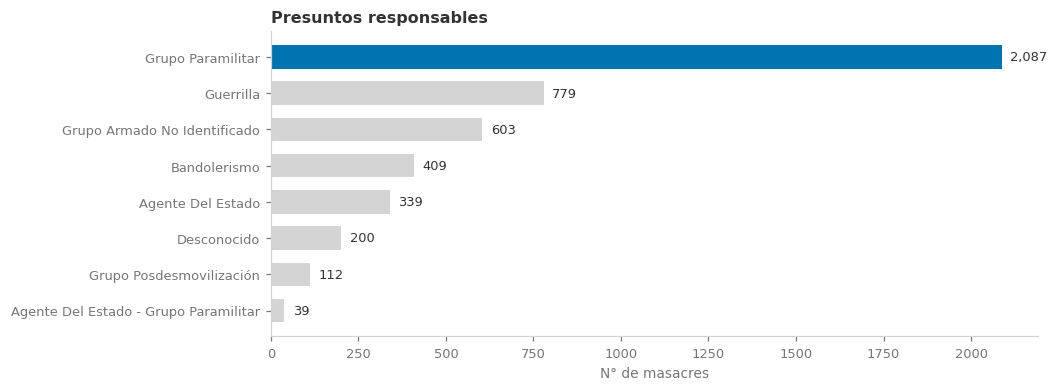

In [12]:
top = resp.head(8).sort_values("masacres")
fig, ax = plt.subplots(figsize=(9, 3.6))
colores = [AZUL if i == top.index[-1] else GRIS for i in top.index]
ax.barh([t.title() for t in top.index], top["masacres"], color=colores, height=.65)
for i, val in enumerate(top["masacres"]):
    ax.text(val+25, i, f"{val:,}", va="center", fontsize=8.5, color=TEXTO)
ax.set_xlabel("N° de masacres"); ax.set_title("Presuntos responsables")
plt.show()

### 4.1 Composición por década

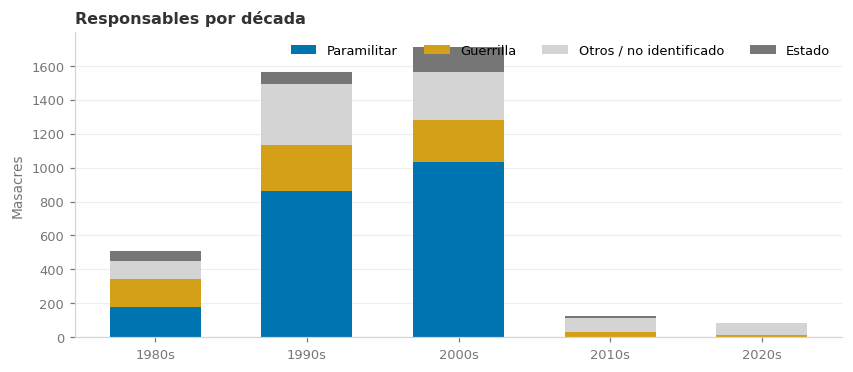

Autoría  Paramilitar  Guerrilla  Otros / no identificado  Estado
Década                                                          
1980            34.5       32.4                     21.2    12.0
1990            55.2       17.1                     23.2     4.5
2000            60.2       14.7                     16.5     8.6
2010             0.0       24.4                     66.9     8.7
2020             0.0       13.1                     85.7     1.2


In [13]:
dt = dt.copy()
dt["Década"] = (dt["Año"]//10*10).astype(int)
grupos_resp = {"GRUPO PARAMILITAR": "Paramilitar", "GUERRILLA": "Guerrilla",
               "AGENTE DEL ESTADO": "Estado"}
dt["Autoría"] = dt["Presunto Responsable"].map(grupos_resp).fillna("Otros / no identificado")

decadas = (dt[dt["Década"].between(1980, 2020)]
           .pivot_table(index="Década", columns="Autoría", values="ID Caso", aggfunc="size")
           .fillna(0))
orden = ["Paramilitar", "Guerrilla", "Otros / no identificado", "Estado"]
decadas = decadas[[c for c in orden if c in decadas.columns]]

fig, ax = plt.subplots(figsize=(9, 3.6))
abajo = np.zeros(len(decadas))
paleta = {"Paramilitar": AZUL, "Guerrilla": "#D4A017",
          "Otros / no identificado": GRIS, "Estado": GRIS_OSC}
for c in decadas.columns:
    ax.bar(decadas.index.astype(str)+"s", decadas[c], bottom=abajo,
           color=paleta[c], label=c, width=.6)
    abajo += decadas[c].values
ax.set_ylabel("Masacres"); ax.set_title("Responsables por década")
ax.legend(ncol=4, loc="upper right"); ax.grid(axis="y"); ax.set_axisbelow(True)
plt.show()

print((100*decadas.div(decadas.sum(axis=1), axis=0)).round(1).to_string())

## 5. Distribución geográfica

La violencia no se repartió de manera uniforme por el territorio. La concentración se puede
afirmar con un porcentaje y medir con un índice.

In [14]:
por_depto = d["Departamento"].value_counts()
por_muni = d["Municipio"].value_counts()

def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = x.size
    return (2*np.sum(np.arange(1, n+1)*x) - (n+1)*x.sum())/(n*x.sum())

print(f"Antioquia: {por_depto.iloc[0]:,} masacres, "
      f"{100*por_depto.iloc[0]/len(d):.1f} % del total nacional")
print(f"Los 5 departamentos más afectados concentran "
      f"{100*por_depto.head(5).sum()/len(d):.1f} %")
print(f"\nGini entre departamentos : {gini(por_depto.values):.3f}")
print(f"Gini entre municipios    : {gini(por_muni.values):.3f}")
print(f"El 10 % de los municipios afectados acumula "
      f"{100*por_muni.head(int(.1*len(por_muni))).sum()/len(d):.1f} % de los casos.")
print(f"\nSegún la Comisión de la Verdad, las masacres se presentaron en el 62 % de los "
      f"municipios\ndel país; este registro documenta {d['Municipio'].nunique()} municipios.")

Antioquia: 1,312 masacres, 28.4 % del total nacional
Los 5 departamentos más afectados concentran 51.1 %

Gini entre departamentos : 0.561
Gini entre municipios    : 0.575
El 10 % de los municipios afectados acumula 45.0 % de los casos.

Según la Comisión de la Verdad, las masacres se presentaron en el 62 % de los municipios
del país; este registro documenta 687 municipios.


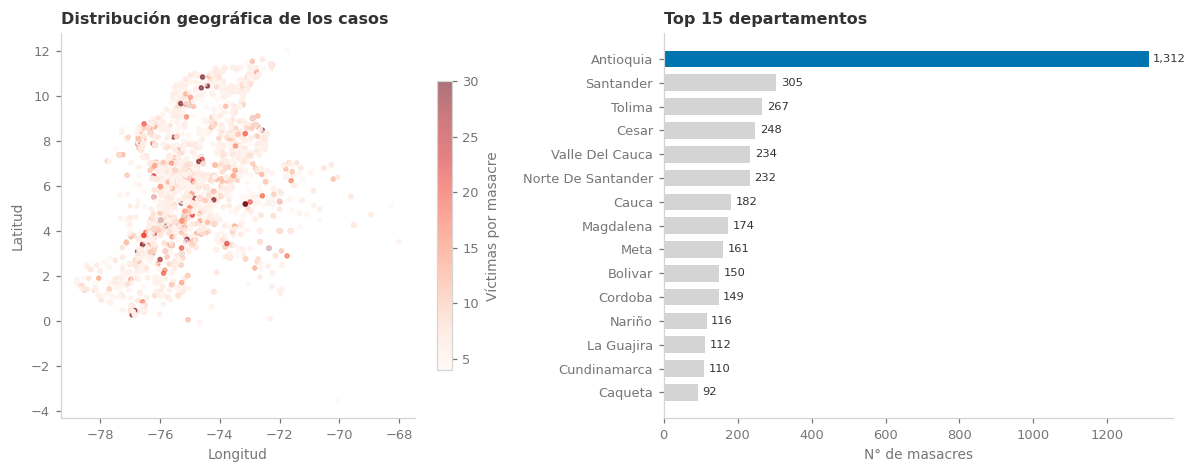

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4),
                       gridspec_kw={"width_ratios": [1, 1.15]})

geo = d.dropna(subset=["latitud", "longitud"])
sc = ax[0].scatter(geo["longitud"], geo["latitud"],
                   c=geo["Total de Víctimas del Caso"], cmap="Reds",
                   s=7, alpha=.55, vmin=4, vmax=30)
ax[0].set_xlabel("Longitud"); ax[0].set_ylabel("Latitud")
ax[0].set_title("Distribución geográfica de los casos")
fig.colorbar(sc, ax=ax[0], shrink=.75, label="Víctimas por masacre")

top15 = por_depto.head(15).sort_values()
colores = [AZUL if i == top15.index[-1] else GRIS for i in top15.index]
ax[1].barh([t.title() for t in top15.index], top15.values, color=colores, height=.7)
for i, val in enumerate(top15.values):
    ax[1].text(val+12, i, f"{val:,}", va="center", fontsize=7.5, color=TEXTO)
ax[1].set_xlabel("N° de masacres"); ax[1].set_title("Top 15 departamentos")

fig.tight_layout(); plt.show()

## 6. Hechos victimizantes simultáneos

Nueve variables registran hechos ocurridos durante el mismo evento. Su estructura de
coocurrencia dice algo que el conteo de víctimas no dice: qué se buscaba además de matar.

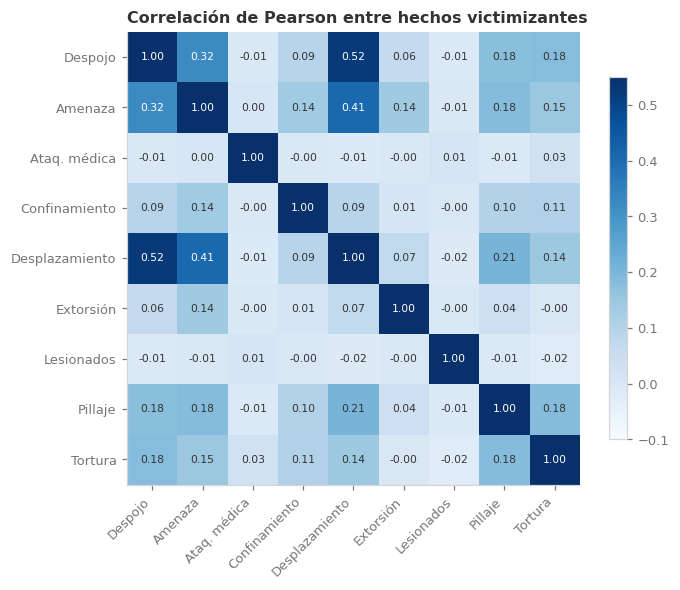

Pares con mayor coocurrencia:
  Abandono o Despojo Forzado de Tierras — Desplazamiento Forzado: r = 0.52
  Amenaza o Intimidación — Desplazamiento Forzado: r = 0.41
  Abandono o Despojo Forzado de Tierras — Amenaza o Intimidación: r = 0.32
  Desplazamiento Forzado — Pillaje: r = 0.21


In [16]:
C = d[hechos].corr()
etiquetas = ["Despojo", "Amenaza", "Ataq. médica", "Confinamiento", "Desplazamiento",
             "Extorsión", "Lesionados", "Pillaje", "Tortura"]

fig, ax = plt.subplots(figsize=(6.6, 5.4))
im = ax.imshow(C, cmap="Blues", vmin=-.1, vmax=.55)
ax.set_xticks(range(9)); ax.set_xticklabels(etiquetas, rotation=45, ha="right")
ax.set_yticks(range(9)); ax.set_yticklabels(etiquetas)
for i in range(9):
    for j in range(9):
        ax.text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if C.iloc[i, j] > .3 else TEXTO)
ax.set_title("Correlación de Pearson entre hechos victimizantes")
fig.colorbar(im, ax=ax, shrink=.8)
fig.tight_layout(); plt.show()

pares = (C.where(np.triu(np.ones(C.shape), 1).astype(bool))
          .stack().sort_values(ascending=False).head(4))
print("Pares con mayor coocurrencia:")
for (a, b), r in pares.items():
    print(f"  {a} — {b}: r = {r:.2f}")

La correlación más alta es despojo–desplazamiento. Leído en conjunto con la coocurrencia de
amenaza y desplazamiento, el patrón es consistente con una estrategia de apropiación territorial:
la masacre como instrumento para vaciar el territorio, no como fin en sí mismo. Es una lectura
del dato, no una prueba causal, y conviene enunciarla así.

In [17]:
n_hechos = d[hechos].sum(axis=1)
rho, p_rho = stats.spearmanr(n_hechos, d["Total de Víctimas del Caso"])

print(f"Correlación de Spearman entre número de hechos simultáneos y víctimas:")
print(f"  rho = {rho:.3f}   p = {p_rho:.2e}   n = {len(d):,}")
print(f"\nSignificativa y muy débil: con n = {len(d):,}, un rho de {rho:.3f} explica alrededor "
      f"del {100*rho**2:.1f} %\nde la variación conjunta. La magnitud de una masacre y la "
      f"cantidad de hechos que la acompañan\nson dimensiones prácticamente independientes.")

Correlación de Spearman entre número de hechos simultáneos y víctimas:
  rho = 0.110   p = 5.66e-14   n = 4,627

Significativa y muy débil: con n = 4,627, un rho de 0.110 explica alrededor del 1.2 %
de la variación conjunta. La magnitud de una masacre y la cantidad de hechos que la acompañan
son dimensiones prácticamente independientes.


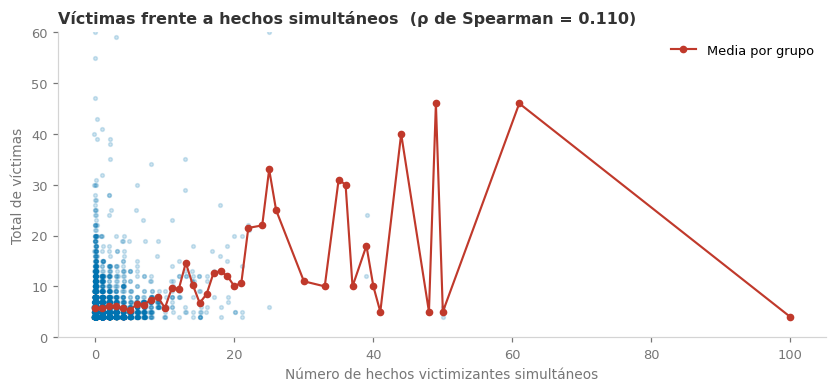

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.6))
jitter = np.random.default_rng(0).normal(0, .08, len(d))
ax.scatter(n_hechos + jitter, d["Total de Víctimas del Caso"],
           s=6, alpha=.18, color=AZUL)
media_grupo = d.groupby(n_hechos)["Total de Víctimas del Caso"].mean()
ax.plot(media_grupo.index, media_grupo.values, "-o", color=ROJO, ms=4, lw=1.4,
        label="Media por grupo")
ax.set_ylim(0, 60)
ax.set_xlabel("Número de hechos victimizantes simultáneos")
ax.set_ylabel("Total de víctimas")
ax.set_title(f"Víctimas frente a hechos simultáneos  (ρ de Spearman = {rho:.3f})")
ax.legend(); plt.show()

## 7. Modalidad y armamento

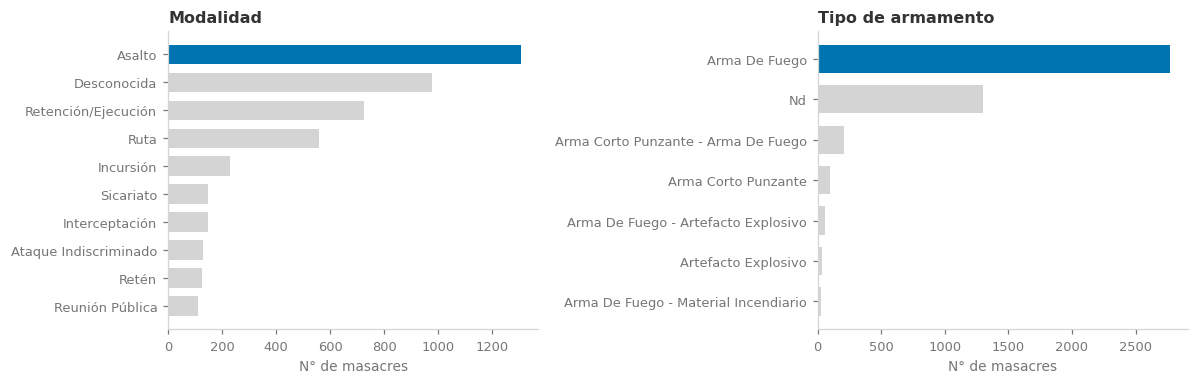

Arma de fuego: 60.0 % de los casos
Modalidad desconocida: 21.1 % — una quinta parte del registro no documenta cómo ocurrió el hecho


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

mod = d["Modalidad"].value_counts().head(10).sort_values()
colores = [AZUL if i == mod.index[-1] else GRIS for i in mod.index]
ax[0].barh([m.title() for m in mod.index], mod.values, color=colores, height=.7)
ax[0].set_title("Modalidad"); ax[0].set_xlabel("N° de masacres")

arm = d["Tipo de Armas"].value_counts().head(7).sort_values()
colores = [AZUL if i == arm.index[-1] else GRIS for i in arm.index]
ax[1].barh([a.title() for a in arm.index], arm.values, color=colores, height=.7)
ax[1].set_title("Tipo de armamento"); ax[1].set_xlabel("N° de masacres")

fig.tight_layout(); plt.show()

print(f"Arma de fuego: {100*(d['Tipo de Armas']=='ARMA DE FUEGO').mean():.1f} % de los casos")
print(f"Modalidad desconocida: {100*(d['Modalidad']=='DESCONOCIDA').mean():.1f} % — "
      f"una quinta parte del registro no documenta cómo ocurrió el hecho")

## 8. Conclusiones

**Sobre el dato.** El archivo exige tratamiento antes de cualquier conteo: separadores de miles
en campos que no son cantidades, coordenadas en formato WKT, fechas desconocidas codificadas como
año cero, y una variable de violencia de género vacía en más del 99 % de los registros. Ninguno
de esos problemas se manifiesta como error: se manifiestan como resultados plausibles y falsos.

**Sobre la concentración temporal.** El período 1996–2003 concentra el 47,4 % de todas las
masacres del registro en ocho de los setenta y ocho años con datos, con un promedio anual de 273
casos frente a 111 del período 1988–1995: dos veces y media más. El año pico es 2001, con 401
masacres y 2.340 víctimas. La caída posterior a la desmovilización de las AUC es la variación más
pronunciada de toda la serie, y el repunte de 2020 la interrumpe.

**Sobre la autoría.** Los grupos paramilitares concentran el 45,1 % de los casos. Las diferencias
en el número de víctimas por caso entre responsables son estadísticamente significativas pero de
magnitud pequeña: la escala de una masacre no depende apreciablemente de quién la comete.

**Sobre el territorio.** La distribución geográfica es fuertemente desigual, con Antioquia
concentrando cerca de tres de cada diez casos. El índice de Gini entre municipios cuantifica esa
concentración.

**Sobre la coocurrencia.** El par despojo–desplazamiento es el de mayor correlación entre los
nueve hechos victimizantes registrados. En cambio, el número de hechos simultáneos y el número de
víctimas son dimensiones prácticamente independientes.

**Sobre los límites.** Según la Comisión de la Verdad, las masacres se presentaron en el 62 % de
los municipios del país. Este dataset es imprescindible y a la vez incompleto, y ninguna cifra de
las anteriores debe leerse como el total de lo ocurrido, sino como el total de lo documentado.

Como escribió el CNMH en *¡Basta ya!*, la memoria es un campo de lucha en el que se decide qué se
recuerda y qué se olvida. Este análisis elige no olvidar.

---

### Referencias

Observatorio de Memoria y Conflicto — Centro Nacional de Memoria Histórica. *Masacres*. Datos
Abiertos de Colombia.

CNMH (2013). *¡Basta ya! Colombia: memorias de guerra y dignidad*.

CNMH (2009). *La masacre de El Salado: esa guerra no era nuestra*.

CNMH (2010). *Bojayá: la guerra sin límites*.

Comisión de la Verdad (2022). *Informe Final — Hay futuro si hay verdad*.

Nussbaumer Knaflic, C. (2015). *Storytelling with Data*. Wiley.

Luis Javier Rubio Hernández